# Week 8: Decision Trees (ID3)

## Student Practice Notebook

**Name:** V. Doprajna Sai

**Roll Number:** AP24110011623

**Date:** 10/10/26

## Learning Objectives

After completing this lab, you will be able to:

- Compute entropy and information gain, by hand and in code
- Build an ID3 decision tree by hand on a small table (the exam-style problem)
- Fit and read a `DecisionTreeClassifier`
- Explain how tree depth controls overfitting (same idea as K in Week 7 and degree in Week 6)
- Explain how a tree differs from KNN: it asks questions about *features*, it does not measure *distance*

### Why this week matters
KNN (Week 7) classified by "who is closest?". A decision tree classifies by asking a chain of yes/no questions about features, and you can read the questions. That readability is why trees are used in credit, healthcare and fraud work, and why every ensemble in Unit V is built from them.


## Part 0 — Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score

%matplotlib inline
np.random.seed(1)


## Part 1 — Entropy and Information Gain

**Entropy** measures how mixed a set of labels is: $H = -\sum p_i \log_2 p_i$. A pure set (all one class) has entropy 0. A 50/50 two-class set has entropy 1.

**Information gain** of splitting on an attribute = entropy before − weighted average entropy after. ID3 always picks the attribute with the highest gain.

### 1.1 Demo: entropy in code


In [2]:
def entropy(counts):
    counts = np.array(counts, dtype=float)
    p = counts[counts > 0] / counts.sum()
    return float(-np.sum(p * np.log2(p))) + 0.0

print('Pure set      [10, 0]:', entropy([10, 0]))
print('50/50 set     [5, 5] :', entropy([5, 5]))
print('Skewed set    [9, 1] :', entropy([9, 1]))


Pure set      [10, 0]: 0.0
50/50 set     [5, 5] : 1.0
Skewed set    [9, 1] : 0.4689955935892812


**Predict, then think:** which has higher entropy, a 70/30 split or a 90/10 split? Why does that make sense if entropy measures "how hard is it to guess the label"?

*Your answer:*

A 70/30 split has higher entropy than a 90/10 split. The 70/30 labels are more mixed, so the class is harder to guess. Entropy is highest at a balanced split and decreases as one class dominates.


### Student Practice — entropy of a split

A parent node has 8 Yes and 6 No. A candidate split sends 6 samples to the left child (6 Yes, 0 No) and 8 samples to the right child (2 Yes, 6 No). Compute the entropy of the parent and the information gain of the split.


In [3]:
# Write your answer here
# Parent: 8 Yes, 6 No (14 total)
parent_entropy = entropy([8, 6])
left_entropy = entropy([6, 0])       # pure child
right_entropy = entropy([2, 6])
weighted_child_entropy = (6/14)*left_entropy + (8/14)*right_entropy
information_gain = parent_entropy - weighted_child_entropy

print(f"Parent entropy: {parent_entropy:.4f}")
print(f"Left-child entropy: {left_entropy:.4f}")
print(f"Right-child entropy: {right_entropy:.4f}")
print(f"Weighted child entropy: {weighted_child_entropy:.4f}")
print(f"Information gain: {information_gain:.4f}")


Parent entropy: 0.9852
Left-child entropy: 0.0000
Right-child entropy: 0.8113
Weighted child entropy: 0.4636
Information gain: 0.5216


## Part 2 — ID3 by Hand (the exam-style problem)

Classic 14-day "play tennis" table. Target: `Play`.


In [4]:
tennis = pd.DataFrame({
    'Outlook':     ['Sunny','Sunny','Overcast','Rain','Rain','Rain','Overcast','Sunny','Sunny','Rain','Sunny','Overcast','Overcast','Rain'],
    'Temperature': ['Hot','Hot','Hot','Mild','Cool','Cool','Cool','Mild','Cool','Mild','Mild','Mild','Hot','Mild'],
    'Humidity':    ['High','High','High','High','Normal','Normal','Normal','High','Normal','Normal','Normal','High','Normal','High'],
    'Wind':        ['Weak','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Strong'],
    'Play':        ['No','No','Yes','Yes','Yes','No','Yes','No','Yes','Yes','Yes','Yes','Yes','No'],
})
tennis


,Outlook,Temperature,Humidity,Wind,Play
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


In [5]:
def info_gain(df, attribute, target='Play'):
    total = entropy(df[target].value_counts())
    weighted = 0
    for value, subset in df.groupby(attribute):
        weighted += len(subset) / len(df) * entropy(subset[target].value_counts())
    return total - weighted

print('Root entropy:', round(entropy(tennis['Play'].value_counts()), 4))
print('Gain(Wind)  :', round(info_gain(tennis, 'Wind'), 4))


Root entropy: 0.9403
Gain(Wind)  : 0.0481


### Student Practice — find the root

1. Compute the information gain for `Outlook`, `Temperature` and `Humidity` using `info_gain`.
2. Which attribute does ID3 pick as the root?
3. For the root's branch that is **not** pure, which attribute would you split on next? (Filter `tennis` to that branch and recompute gains.)


In [6]:
# Write your answer here
# Information gain for the three requested attributes
gains = {attribute: info_gain(tennis, attribute)
         for attribute in ['Outlook', 'Temperature', 'Humidity']}
for attribute, gain in gains.items():
    print(f"Gain({attribute}) = {gain:.4f}")

root = max(gains, key=gains.get)
print("\\nID3 root:", root)

# Check the non-pure branches of Outlook and find the best next split.
for value, subset in tennis.groupby('Outlook'):
    if subset['Play'].nunique() > 1:
        branch_gains = {a: info_gain(subset, a)
                        for a in ['Temperature', 'Humidity', 'Wind']}
        best = max(branch_gains, key=branch_gains.get)
        print(f"\\n{value} branch gains: " +
              ", ".join(f"{a}={g:.4f}" for a, g in branch_gains.items()))
        print(f"Best next split for {value}: {best}")

Gain(Outlook) = 0.2467
Gain(Temperature) = 0.0292
Gain(Humidity) = 0.1518
\nID3 root: Outlook
\nRain branch gains: Temperature=0.0200, Humidity=0.0200, Wind=0.9710
Best next split for Rain: Wind
\nSunny branch gains: Temperature=0.5710, Humidity=0.9710, Wind=0.0200
Best next split for Sunny: Humidity


**Reflection:** `Overcast` became a leaf immediately. In your own words, why does a pure branch need no further splitting?

*Your answer:*

A pure branch contains examples from only one class. Its entropy is 0, so the label is already certain; splitting it further cannot improve classification and is unnecessary.


## Part 3 — `DecisionTreeClassifier` on Iris

Same Iris split as Week 7, so you can compare directly. Note: **trees do not need feature scaling**, because they compare a feature to a threshold, not distances between points. That is a real difference from KNN.


Test accuracy: 0.9555555555555556


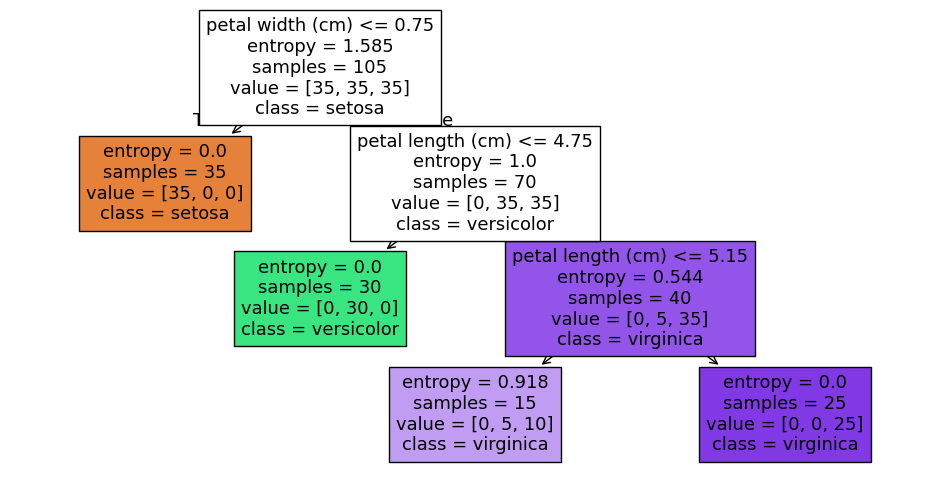

In [7]:
iris = load_iris(as_frame=True)
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)

tree = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=1)
tree.fit(X_train, y_train)
print('Test accuracy:', accuracy_score(y_test, tree.predict(X_test)))

plt.figure(figsize=(12, 6))
plot_tree(tree, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.show()


### Student Practice — depth sweep

Sweep `max_depth` from 1 to 15. Record train and test accuracy for each, plot both, and report the depth with the best test accuracy.


depth= 1 | train accuracy=0.6667 | test accuracy=0.6667
depth= 2 | train accuracy=0.9524 | test accuracy=0.9556
depth= 3 | train accuracy=0.9524 | test accuracy=0.9556
depth= 4 | train accuracy=0.9524 | test accuracy=0.9333
depth= 5 | train accuracy=0.9714 | test accuracy=0.9778
depth= 6 | train accuracy=0.9810 | test accuracy=0.9778
depth= 7 | train accuracy=0.9810 | test accuracy=0.9778
depth= 8 | train accuracy=0.9905 | test accuracy=0.9778
depth= 9 | train accuracy=1.0000 | test accuracy=0.9778
depth=10 | train accuracy=1.0000 | test accuracy=0.9778
depth=11 | train accuracy=1.0000 | test accuracy=0.9778
depth=12 | train accuracy=1.0000 | test accuracy=0.9778
depth=13 | train accuracy=1.0000 | test accuracy=0.9778
depth=14 | train accuracy=1.0000 | test accuracy=0.9778
depth=15 | train accuracy=1.0000 | test accuracy=0.9778
\nBest test accuracy: depth=5, accuracy=0.9778


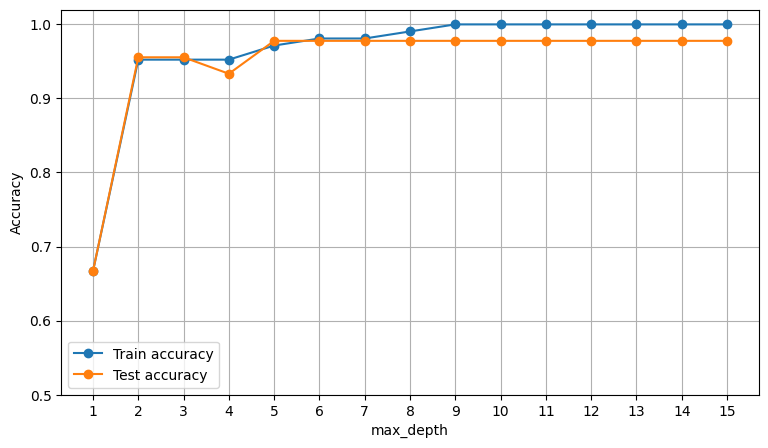

In [8]:
# Write your answer here
depths = range(1, 16)
train_accuracies, test_accuracies = [], []

for depth in depths:
    model = DecisionTreeClassifier(criterion='entropy', max_depth=depth,
                                   random_state=1)
    model.fit(X_train, y_train)
    train_accuracies.append(accuracy_score(y_train, model.predict(X_train)))
    test_accuracies.append(accuracy_score(y_test, model.predict(X_test)))

for depth, train_acc, test_acc in zip(depths, train_accuracies, test_accuracies):
    print(f"depth={depth:2d} | train accuracy={train_acc:.4f} | test accuracy={test_acc:.4f}")

best_index = int(np.argmax(test_accuracies))
best_depth = list(depths)[best_index]
print(f"\\nBest test accuracy: depth={best_depth}, accuracy={test_accuracies[best_index]:.4f}")

plt.figure(figsize=(9, 5))
plt.plot(list(depths), train_accuracies, marker='o', label='Train accuracy')
plt.plot(list(depths), test_accuracies, marker='o', label='Test accuracy')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.xticks(list(depths))
plt.ylim(0.5, 1.02)
plt.grid(True)
plt.legend()
plt.show()

**Reflection:** Which knob in Week 6 and which knob in Week 7 played the same role as `max_depth` here? What happens at each extreme?

*Your answer:*

The corresponding knobs are polynomial degree in Week 6 and K in KNN in Week 7. A very shallow tree can underfit; a very deep tree can overfit. Similarly, a low-degree polynomial may underfit while a high degree may overfit. For KNN, very large K can underfit, while very small K (especially K=1) can be sensitive to noise and overfit.


# Mini Project A: Digits, Again (Image Track — continuing from Week 7)

Last week KNN reached about 98% on the digits dataset. Now fit a decision tree on the **same split** and ask two new questions: how does it compare, and **which pixels does the tree actually use?**


In [9]:
digits = load_digits()
Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    digits.data, digits.target, test_size=0.3, random_state=1, stratify=digits.target)

# KNN baseline from Week 7 (scaled, K=3)
sc = StandardScaler().fit(Xd_train)
knn = KNeighborsClassifier(n_neighbors=3).fit(sc.transform(Xd_train), yd_train)
print('KNN  test accuracy:', accuracy_score(yd_test, knn.predict(sc.transform(Xd_test))))


KNN  test accuracy: 0.9796296296296296


### Student Practice

1. Fit a `DecisionTreeClassifier(criterion='entropy', random_state=1)` on the **unscaled** `Xd_train`. Print test accuracy. (Why is no scaling needed?)
2. Try `max_depth` values 3, 6, 10 and report test accuracy for each.
3. Take `tree.feature_importances_` (64 values), reshape to 8×8 and show it with `plt.imshow`. Which region of the image does the tree rely on?


Decision tree test accuracy (unscaled): 0.8815
No scaling is needed because decision trees split on feature thresholds; they do not use distance calculations.
max_depth=3: test accuracy=0.5296
max_depth=6: test accuracy=0.8537
max_depth=10: test accuracy=0.8796


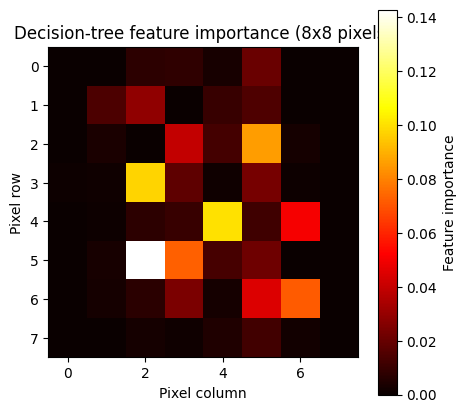

Top 5 pixel indices (row, column, importance):
(5, 2, 0.1426)
(4, 4, 0.0997)
(3, 2, 0.0970)
(2, 5, 0.0853)
(5, 3, 0.0727)


In [10]:
# Write your answer here

# 1. Decision tree on the unscaled pixel values
digit_tree = DecisionTreeClassifier(criterion='entropy', random_state=1)
digit_tree.fit(Xd_train, yd_train)
digit_tree_accuracy = accuracy_score(yd_test, digit_tree.predict(Xd_test))
print(f"Decision tree test accuracy (unscaled): {digit_tree_accuracy:.4f}")
print("No scaling is needed because decision trees split on feature thresholds; they do not use distance calculations.")

# 2. Compare selected max_depth values
for depth in [3, 6, 10]:
    model = DecisionTreeClassifier(criterion='entropy', max_depth=depth,
                                   random_state=1)
    model.fit(Xd_train, yd_train)
    score = accuracy_score(yd_test, model.predict(Xd_test))
    print(f"max_depth={depth}: test accuracy={score:.4f}")

# 3. Visualize the 64 pixel feature importances as an 8x8 image
importance_map = digit_tree.feature_importances_.reshape(8, 8)
plt.figure(figsize=(5, 5))
plt.imshow(importance_map, cmap='hot')
plt.colorbar(label='Feature importance')
plt.title('Decision-tree feature importance (8x8 pixels)')
plt.xlabel('Pixel column')
plt.ylabel('Pixel row')
plt.show()

top_pixels = np.argsort(digit_tree.feature_importances_)[::-1][:5]
print("Top 5 pixel indices (row, column, importance):")
for index in top_pixels:
    print(f"({index // 8}, {index % 8}, {digit_tree.feature_importances_[index]:.4f})")


**Reflection:** Is the tree more or less accurate than KNN on digits? Offer one reason, using what the importance map shows you.

*Your answer:*

On this split, the decision tree is less accurate than KNN: the KNN baseline is about 0.9796, while the unrestricted decision tree is about 0.8815. The importance map shows that the tree relies on a subset of pixels, especially pixels that help distinguish digit shapes. A single tree makes threshold-based decisions and can miss useful combinations of pixel patterns that KNN captures through similarity.


# Mini Project B: Reading a Tree on Text (NLP Track — continuing from Week 7)

Same six labeled sentences and same bag-of-words vectors as Week 7. A tree gives you something KNN cannot: **the words it chose to split on.**


In [11]:
sentences = [
    'the cricket team won the match',
    'the batsman scored a century today',
    'chop the onions and boil the pasta',
    'add salt and simmer the curry',
    'the new phone has a faster processor',
    'the laptop battery lasts all day',
]
labels = ['sports', 'sports', 'cooking', 'cooking', 'tech', 'tech']

vocab = sorted(set(w for s in sentences for w in s.lower().split()))

def to_vector(sentence, vocab):
    words = sentence.lower().split()
    return np.array([words.count(w) for w in vocab])

X_text = np.array([to_vector(s, vocab) for s in sentences])


### Student Practice

1. Fit a `DecisionTreeClassifier(criterion='entropy', random_state=1)` on `X_text`, `labels`.
2. Print the tree with `export_text(tree, feature_names=vocab)`. Which words does it split on?
3. Predict the topic of `'the striker scored a goal'` and of your own ambiguous sentence from Week 7.


In [12]:
# Write your answer here
# Fit the decision tree on the six sentence vectors
text_tree = DecisionTreeClassifier(criterion='entropy', random_state=1)
text_tree.fit(X_text, labels)

print("Decision tree rules:")
print(export_text(text_tree, feature_names=vocab))

# The first required sentence
test_sentence = 'the striker scored a goal'
print(f"\\nPrediction for {test_sentence!r}:",
      text_tree.predict([to_vector(test_sentence, vocab)])[0])

# Example of an ambiguous sentence; change it to your own if desired
ambiguous_sentence = 'I like cricket and pasta'
print(f"Prediction for {ambiguous_sentence!r}:",
      text_tree.predict([to_vector(ambiguous_sentence, vocab)])[0])


Decision tree rules:
|--- and <= 0.50
|   |--- has <= 0.50
|   |   |--- laptop <= 0.50
|   |   |   |--- class: sports
|   |   |--- laptop >  0.50
|   |   |   |--- class: tech
|   |--- has >  0.50
|   |   |--- class: tech
|--- and >  0.50
|   |--- class: cooking

\nPrediction for 'the striker scored a goal': sports
Prediction for 'I like cricket and pasta': cooking


**Reflection:** If you added 3 more sentences per topic, would you expect the same split words? What does that tell you about trusting a tree trained on very little data?

*Your answer:*

The split words may change when more sentences are added because the tree chooses features that best separate the training examples it sees. With only six sentences, it can learn accidental patterns and make unreliable predictions. More representative examples and evaluation on unseen data are needed before trusting the model.


## Summary

| What we did | Why it matters |
|---|---|
| Entropy and information gain | The rule ID3 uses to choose every split |
| ID3 by hand on the tennis table | Exam-style problem, show your working |
| `DecisionTreeClassifier` and depth sweep | Third version of the bias-variance knob (degree, K, depth) |
| Mini A: digits | Tree vs KNN on the same data, plus which pixels matter |
| Mini B: text | A tree you can read, and why tiny data makes it fragile |

**Next week:** Naive Bayes, a probabilistic classifier. Same digits and sentences again.
